# Model 1: Logistic Regression Pipeline

### Architecture
1. **Preprocessor**: `ColumnTransformer` (Median Imputation + `StandardScaler` for continuous features; Most-Frequent Imputation + `OneHotEncoder(drop='first')` for categoricals).
2. **Estimator**: `LogisticRegression(max_iter=1000, random_state=42)`.

### Operational Rationale
Logistic Regression serves as the gold-standard benchmark in credit scoring:
- Generates well-calibrated probabilistic scores: $P(Y=1 \mid X) = \sigma(w^T X + b)$.
- Produces interpretable log-odds coefficients.
- Scales linearly and operates without computational latency in production.

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Load data and clean
df = pd.read_csv("data/raw/loan_data_set.csv")
df_clean = df.drop(columns=["Loan_ID"]).copy()
target_mapping = {"Y": 1, "N": 0}
df_clean["Loan_Status"] = df_clean["Loan_Status"].map(target_mapping)

X = df_clean.drop(columns=["Loan_Status"])
y = df_clean["Loan_Status"].astype(int)

# 2. Stratified train-test split (identical seed as Notebook 1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Define column groups
num_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]
cat_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Credit_History", "Property_Area"]

# 4. Build preprocessor
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

print("Preprocessor, X_train, and y_train loaded successfully.")

Preprocessor, X_train, and y_train loaded successfully.


In [6]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Construct unified pipeline: Preprocessing -> Estimator
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit on training data ONLY
lr_pipeline.fit(X_train, y_train)

print("Logistic Regression pipeline trained successfully.")

Logistic Regression pipeline trained successfully.


/Users/yash/Desktop/loan_approval_intelligence/.venv/lib/python3.14/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yash/Desktop/loan_approval_intelligence/.venv/lib/python3.14/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yash/Desktop/loan_approval_intelligence/.venv/lib/python3.14/site-packages/sklearn/linear_model/_linear_loss.py:165: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/yash/Desktop/loan_approval_intelligence/.venv/lib/python3.14/site-packages/sklearn/linear_model/_linear_loss.py:295: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/yash/Desktop/loan_approval_intelligence/.venv/lib/python3.14/site-packages/sklearn/linear_mo

Standard Evaluation ($Threshold = 0.50$)

In [7]:
# Generate hard predictions and calibrated positive-class probabilities
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Calculate core metrics
acc = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr)
rec = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_proba_lr)

print("=" * 45)
print("  LOGISTIC REGRESSION PERFORMANCE (Threshold = 0.50)")
print("=" * 45)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred_lr, target_names=["Rejected (0)", "Approved (1)"]))

  LOGISTIC REGRESSION PERFORMANCE (Threshold = 0.50)
Accuracy : 0.8618
Precision: 0.8400
Recall   : 0.9882
F1-Score : 0.9081
ROC-AUC  : 0.8517

--- Detailed Classification Report ---
              precision    recall  f1-score   support

Rejected (0)       0.96      0.58      0.72        38
Approved (1)       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



/Users/yash/Desktop/loan_approval_intelligence/.venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yash/Desktop/loan_approval_intelligence/.venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yash/Desktop/loan_approval_intelligence/.venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yash/Desktop/loan_approval_intelligence/.venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yash/Desktop/loan_approval_intelligence/.venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yash/Desktop/loan_approval_intelligence/.venv/lib/python3.14/site-packages/sklearn/utils/extmath.py:205: Runtim

Confusion Matrix Visualization

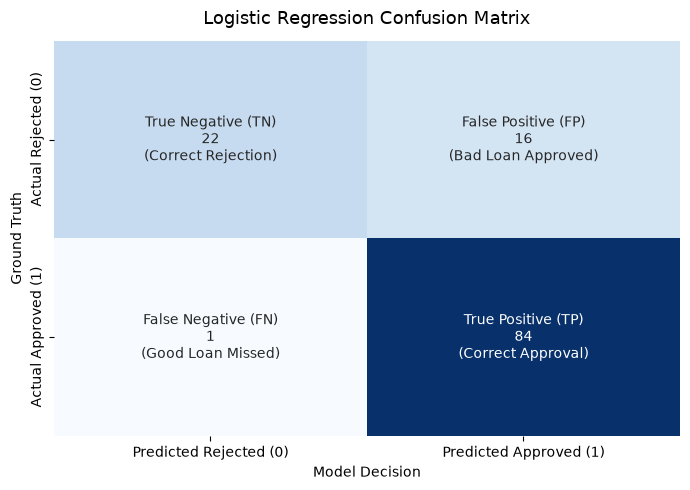

In [8]:
cm = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 5))
labels = [
    [f"True Negative (TN)\n{tn}\n(Correct Rejection)", f"False Positive (FP)\n{fp}\n(Bad Loan Approved)"],
    [f"False Negative (FN)\n{fn}\n(Good Loan Missed)", f"True Positive (TP)\n{tp}\n(Correct Approval)"]
]

sns.heatmap(
    cm, 
    annot=labels, 
    fmt="", 
    cmap="Blues", 
    cbar=False,
    xticklabels=["Predicted Rejected (0)", "Predicted Approved (1)"],
    yticklabels=["Actual Rejected (0)", "Actual Approved (1)"]
)
plt.title("Logistic Regression Confusion Matrix", fontsize=13, pad=12)
plt.ylabel("Ground Truth")
plt.xlabel("Model Decision")
plt.tight_layout()
plt.show()

Credit Risk Confusion Matrix Interpretation

### Credit Risk Interpretation of the Confusion Matrix

| Metric Outcome | Operational Reality in Lending | Relative Business Cost |
| :--- | :--- | :--- |
| **True Positive (TP)** | A creditworthy applicant was correctly approved. The bank generates interest revenue without default friction. | Revenue-generating |
| **True Negative (TN)** | A high-risk applicant was correctly declined. Capital preservation succeeded. | Risk-mitigating |
| **False Positive (FP)** | **Type I Error:** A high-risk applicant was approved. This results in **loan default**, charge-offs, legal recovery costs, and capital loss. | **High Direct Cost** |
| **False Negative (FN)** | **Type II Error:** A creditworthy applicant was declined. This results in lost interest margin and borrower churn to a competitor. | Opportunity Cost |

> **Asymmetry of Risk**: In retail lending, the capital lost from a single **False Positive** (e.g., losing a $150,000 principal) typically requires 15 to 25 **True Positives** (earning a 4–6% net margin) to break even. Minimizing False Positives is usually prioritized over eliminating False Negatives.

Decision Threshold Analysis

In [9]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results = []

for t in thresholds:
    preds_t = (y_proba_lr >= t).astype(int)
    cm_t = confusion_matrix(y_test, preds_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    threshold_results.append({
        "Threshold": f"{t:.2f}",
        "Precision": round(precision_score(y_test, preds_t, zero_division=0), 4),
        "Recall": round(recall_score(y_test, preds_t, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, preds_t, zero_division=0), 4),
        "FP (Bad Loans)": fp_t,
        "FN (Lost Deals)": fn_t
    })

thresh_df = pd.DataFrame(threshold_results)
display(thresh_df)

,Threshold,Precision,Recall,F1-Score,FP (Bad Loans),FN (Lost Deals)
0,0.30,0.8317,0.9882,0.9032,17,1
1,0.40,0.8400,0.9882,0.9081,16,1
2,0.50,0.8400,0.9882,0.9081,16,1
3,0.60,0.8542,0.9647,0.9061,14,3
4,0.70,0.8675,0.8471,0.8571,11,13


Feature Association (Logistic Coefficients)

--- Top Features Influencing Logistic Regression Decisions ---


,Feature,Coefficient (Log-Odds),Odds Ratio
0,Credit_History_1.0,3.161051,23.595378
1,Property_Area_Semiurban,0.727417,2.069728
2,Married_Yes,0.519759,1.681623
3,Dependents_2,0.345283,1.412389
4,Dependents_3+,0.145246,1.156324
5,Property_Area_Urban,0.129215,1.137935
6,ApplicantIncome,0.000614,1.000614
7,Loan_Amount_Term,-0.017403,0.982748
8,LoanAmount,-0.034035,0.966538
9,CoapplicantIncome,-0.145367,0.864705


/var/folders/yr/pyshnq8j1hqfvl52ws7vyyj40000gn/T/ipykernel_33255/4010893644.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coeff_df, x="Coefficient (Log-Odds)", y="Feature", palette=colors)


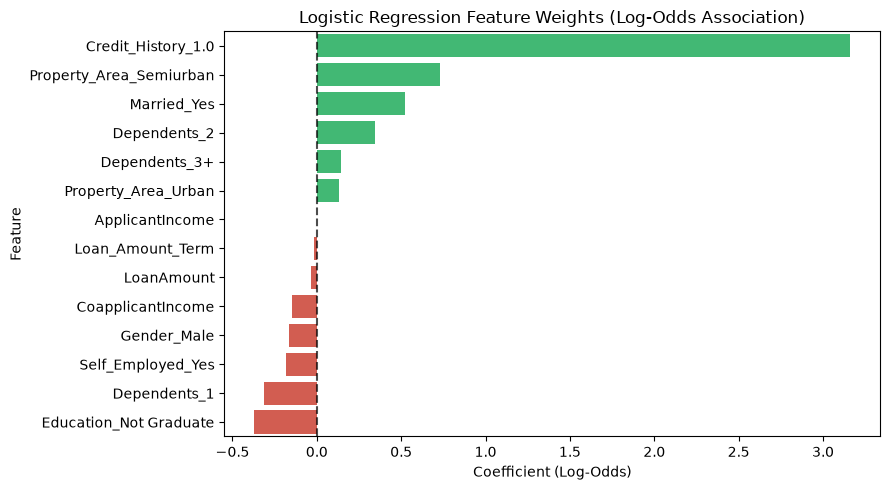

In [10]:
# Extract one-hot encoded column names
ohe_names = lr_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_cols)
encoded_feature_names = list(num_cols) + list(ohe_names)

# Extract logistic weights
coefficients = lr_pipeline.named_steps["classifier"].coef_[0]

coeff_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Coefficient (Log-Odds)": coefficients,
    "Odds Ratio": np.exp(coefficients)
}).sort_values(by="Coefficient (Log-Odds)", ascending=False).reset_index(drop=True)

print("--- Top Features Influencing Logistic Regression Decisions ---")
display(coeff_df)

# Plot top weights
plt.figure(figsize=(9, 5))
colors = ["#2ecc71" if c > 0 else "#e74c3c" for c in coeff_df["Coefficient (Log-Odds)"]]
sns.barplot(data=coeff_df, x="Coefficient (Log-Odds)", y="Feature", palette=colors)
plt.title("Logistic Regression Feature Weights (Log-Odds Association)", fontsize=12)
plt.axvline(0, color="black", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Serialize Pipeline for Deployment

In [11]:
# Save the complete pipeline (preprocessor + model)
model_filename = "logistic_regression_pipeline.joblib"
joblib.dump(lr_pipeline, model_filename)

print(f"Pipeline successfully serialized and saved to: '{model_filename}'")

Pipeline successfully serialized and saved to: 'logistic_regression_pipeline.joblib'


# Model 2: Decision Tree Classifier Pipeline

### Architecture & Hyperparameter Rationale
- **Preprocessor**: Reuses the validated `ColumnTransformer` (median/mode imputation, one-hot encoding).
- **Estimator**: `DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)`
- **Constraint Strategy**: An unconstrained decision tree splits until leaves are pure, leading to severe overfitting on small lending samples (capturing noise in high applicant incomes). Setting `max_depth=4` and `min_samples_leaf=10` creates a regularized, interpretable tree suitable for compliance audits.

Train End-to-End Decision Tree Pipeline

In [12]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Define pipeline with regularized Decision Tree
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=4, 
        min_samples_leaf=10, 
        random_state=42
    ))
])

# Train on training set ONLY
dt_pipeline.fit(X_train, y_train)

print("Decision Tree pipeline trained successfully.")

Decision Tree pipeline trained successfully.


Evaluation ($Threshold = 0.50$)

In [13]:
# Hard predictions and probabilities
y_pred_dt = dt_pipeline.predict(X_test)
y_proba_dt = dt_pipeline.predict_proba(X_test)[:, 1]

# Core metrics
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)

print("=" * 45)
print("  DECISION TREE PERFORMANCE (Threshold = 0.50)")
print("=" * 45)
print(f"Accuracy : {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall   : {rec_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {roc_auc_dt:.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred_dt, target_names=["Rejected (0)", "Approved (1)"]))

  DECISION TREE PERFORMANCE (Threshold = 0.50)
Accuracy : 0.8211
Precision: 0.8316
Recall   : 0.9294
F1-Score : 0.8778
ROC-AUC  : 0.7724

--- Detailed Classification Report ---
              precision    recall  f1-score   support

Rejected (0)       0.79      0.58      0.67        38
Approved (1)       0.83      0.93      0.88        85

    accuracy                           0.82       123
   macro avg       0.81      0.75      0.77       123
weighted avg       0.82      0.82      0.81       123



Confusion Matrix Visualization & Error Analysis

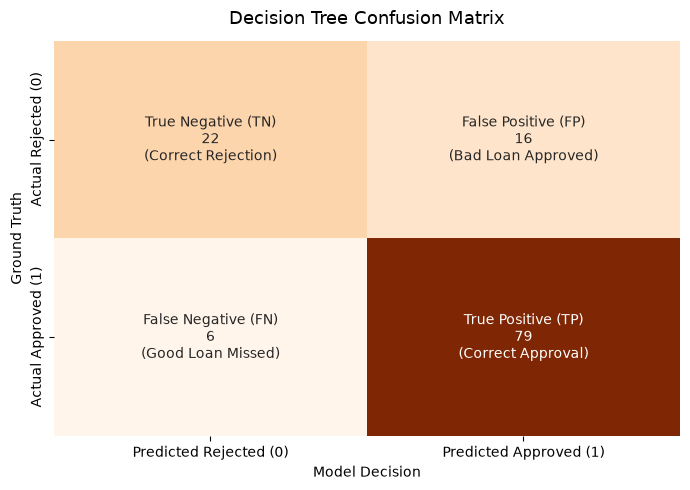

In [14]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()

plt.figure(figsize=(7, 5))
labels_dt = [
    [f"True Negative (TN)\n{tn_dt}\n(Correct Rejection)", f"False Positive (FP)\n{fp_dt}\n(Bad Loan Approved)"],
    [f"False Negative (FN)\n{fn_dt}\n(Good Loan Missed)", f"True Positive (TP)\n{tp_dt}\n(Correct Approval)"]
]

sns.heatmap(
    cm_dt, 
    annot=labels_dt, 
    fmt="", 
    cmap="Oranges", 
    cbar=False,
    xticklabels=["Predicted Rejected (0)", "Predicted Approved (1)"],
    yticklabels=["Actual Rejected (0)", "Actual Approved (1)"]
)
plt.title("Decision Tree Confusion Matrix", fontsize=13, pad=12)
plt.ylabel("Ground Truth")
plt.xlabel("Model Decision")
plt.tight_layout()
plt.show()

Decision Threshold Analysis

In [15]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results_dt = []

for t in thresholds:
    preds_t = (y_proba_dt >= t).astype(int)
    cm_t = confusion_matrix(y_test, preds_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    threshold_results_dt.append({
        "Threshold": f"{t:.2f}",
        "Precision": round(precision_score(y_test, preds_t, zero_division=0), 4),
        "Recall": round(recall_score(y_test, preds_t, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, preds_t, zero_division=0), 4),
        "FP (Bad Loans)": fp_t,
        "FN (Lost Deals)": fn_t
    })

thresh_df_dt = pd.DataFrame(threshold_results_dt)
print("--- Decision Tree Threshold Sensitivity ---")
display(thresh_df_dt)

--- Decision Tree Threshold Sensitivity ---


,Threshold,Precision,Recall,F1-Score,FP (Bad Loans),FN (Lost Deals)
0,0.30,0.8000,0.9882,0.8842,21,1
1,0.40,0.8317,0.9882,0.9032,17,1
2,0.50,0.8316,0.9294,0.8778,16,6
3,0.60,0.8316,0.9294,0.8778,16,6
4,0.70,0.8442,0.7647,0.8025,12,20


Feature Importance & Decision Tree Structure

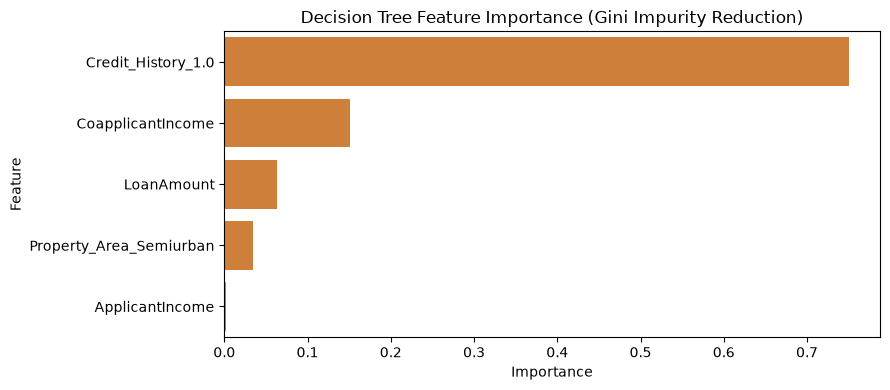

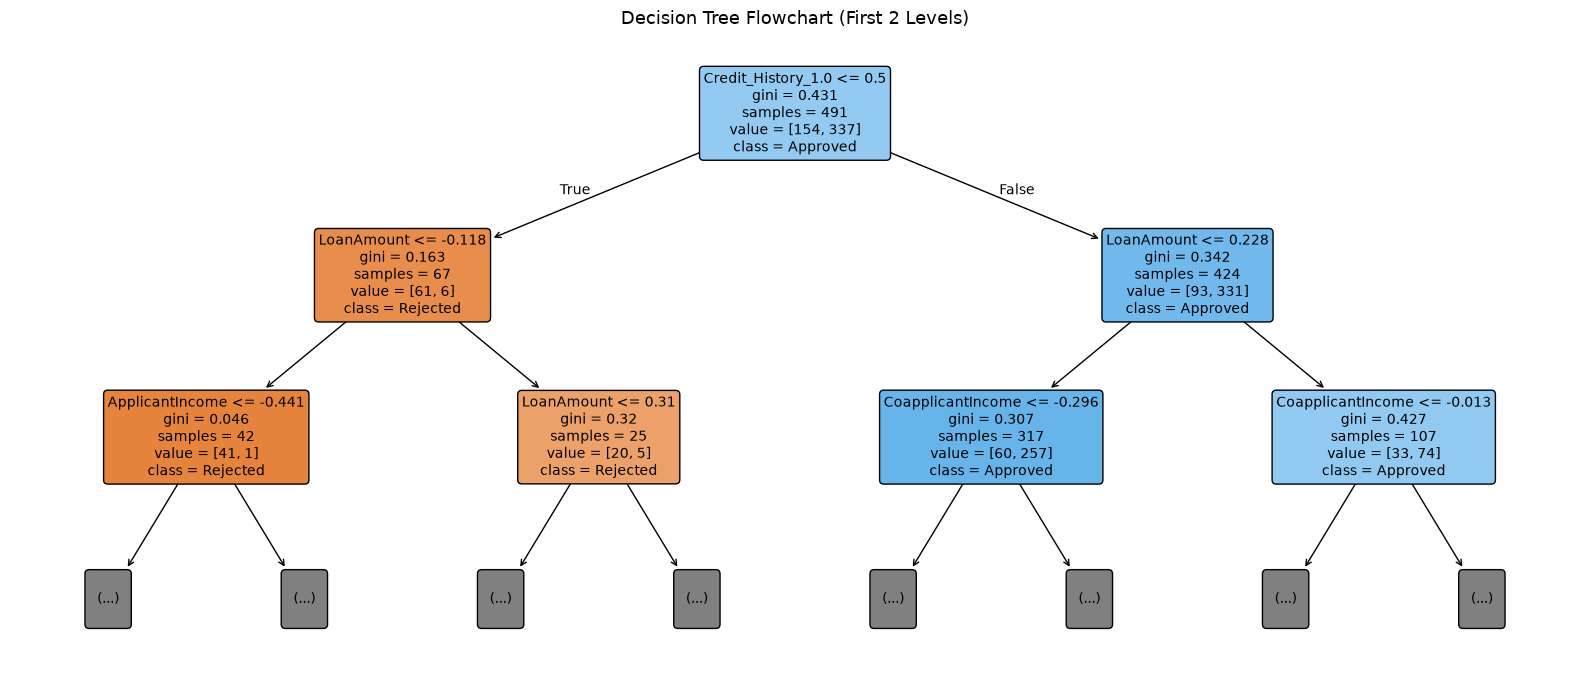

In [16]:
# Extract feature names post-encoding
ohe_names = dt_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_cols)
encoded_feature_names = list(num_cols) + list(ohe_names)

# Gini Importance
dt_clf = dt_pipeline.named_steps["classifier"]
importances = dt_clf.feature_importances_

fi_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Plot Feature Importance
plt.figure(figsize=(9, 4))
sns.barplot(data=fi_df[fi_df["Importance"] > 0], x="Importance", y="Feature", color="#e67e22")
plt.title("Decision Tree Feature Importance (Gini Impurity Reduction)", fontsize=12)
plt.tight_layout()
plt.show()

# Visual Tree Hierarchy (top 2 levels for interpretability)
plt.figure(figsize=(16, 7))
plot_tree(
    dt_clf, 
    max_depth=2, 
    feature_names=encoded_feature_names, 
    class_names=["Rejected", "Approved"], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Decision Tree Flowchart (First 2 Levels)", fontsize=13)
plt.tight_layout()
plt.show()

Serialize Pipeline

In [17]:
dt_filename = "decision_tree_pipeline.joblib"
joblib.dump(dt_pipeline, dt_filename)

print(f"Pipeline successfully serialized and saved to: '{dt_filename}'")

Pipeline successfully serialized and saved to: 'decision_tree_pipeline.joblib'


# Model 3: Random Forest Classifier Pipeline

### Architecture & Hyperparameter Rationale
- **Preprocessor**: Reuses the validated `ColumnTransformer` (ensures zero data leakage).
- **Estimator**: `RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_split=5, min_samples_leaf=4, random_state=42)`
- **Design Strategy**: A single decision tree suffers from high variance (sensitivity to sample variations). Random Forest aggregates decorrelated trees using bootstrap aggregation (bagging) and random feature subspace sampling, dampening overfitting on noisy financial attributes like `ApplicantIncome` while yielding continuous probability distributions.

Train End-to-End Random Forest Pipeline

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Define pipeline with regularized Random Forest
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_split=5,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

# Train on training data ONLY
rf_pipeline.fit(X_train, y_train)

print("Random Forest pipeline trained successfully.")

Random Forest pipeline trained successfully.


 Evaluation ($Threshold = 0.50$)

In [19]:
# Predictions and calibrated ensemble probabilities
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Core metrics
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("=" * 45)
print("  RANDOM FOREST PERFORMANCE (Threshold = 0.50)")
print("=" * 45)
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall   : {rec_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=["Rejected (0)", "Approved (1)"]))

  RANDOM FOREST PERFORMANCE (Threshold = 0.50)
Accuracy : 0.8537
Precision: 0.8317
Recall   : 0.9882
F1-Score : 0.9032
ROC-AUC  : 0.8046

--- Detailed Classification Report ---
              precision    recall  f1-score   support

Rejected (0)       0.95      0.55      0.70        38
Approved (1)       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



Confusion Matrix Visualization & Business Cost Breakdown

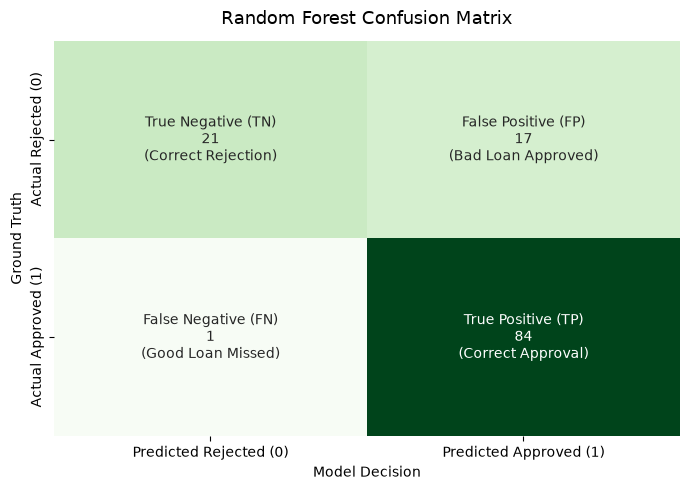

In [20]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn_rf, fp_rf, fn_rf, tp_rf = cm_rf.ravel()

plt.figure(figsize=(7, 5))
labels_rf = [
    [f"True Negative (TN)\n{tn_rf}\n(Correct Rejection)", f"False Positive (FP)\n{fp_rf}\n(Bad Loan Approved)"],
    [f"False Negative (FN)\n{fn_rf}\n(Good Loan Missed)", f"True Positive (TP)\n{tp_rf}\n(Correct Approval)"]
]

sns.heatmap(
    cm_rf, 
    annot=labels_rf, 
    fmt="", 
    cmap="Greens", 
    cbar=False,
    xticklabels=["Predicted Rejected (0)", "Predicted Approved (1)"],
    yticklabels=["Actual Rejected (0)", "Actual Approved (1)"]
)
plt.title("Random Forest Confusion Matrix", fontsize=13, pad=12)
plt.ylabel("Ground Truth")
plt.xlabel("Model Decision")
plt.tight_layout()
plt.show()

Decision Threshold Analysis

In [21]:
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results_rf = []

for t in thresholds:
    preds_t = (y_proba_rf >= t).astype(int)
    cm_t = confusion_matrix(y_test, preds_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    
    threshold_results_rf.append({
        "Threshold": f"{t:.2f}",
        "Precision": round(precision_score(y_test, preds_t, zero_division=0), 4),
        "Recall": round(recall_score(y_test, preds_t, zero_division=0), 4),
        "F1-Score": round(f1_score(y_test, preds_t, zero_division=0), 4),
        "FP (Bad Loans)": fp_t,
        "FN (Lost Deals)": fn_t
    })

thresh_df_rf = pd.DataFrame(threshold_results_rf)
print("--- Random Forest Threshold Sensitivity ---")
display(thresh_df_rf)

--- Random Forest Threshold Sensitivity ---


,Threshold,Precision,Recall,F1-Score,FP (Bad Loans),FN (Lost Deals)
0,0.30,0.7500,0.9882,0.8528,28,1
1,0.40,0.8317,0.9882,0.9032,17,1
2,0.50,0.8317,0.9882,0.9032,17,1
3,0.60,0.8526,0.9529,0.9000,14,4
4,0.70,0.8415,0.8118,0.8263,13,16


Ensemble Feature Importance (Mean Decrease in Impurity)

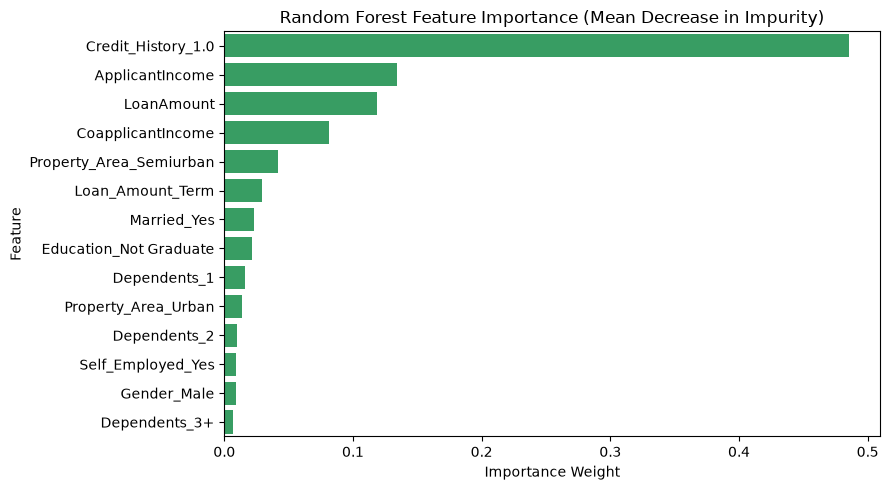

--- Top 5 Features in Random Forest ---


,Feature,Importance
0,Credit_History_1.0,0.485319
1,ApplicantIncome,0.134475
2,LoanAmount,0.118920
3,CoapplicantIncome,0.081223
4,Property_Area_Semiurban,0.041373


In [22]:
# Feature extraction
ohe_names = rf_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_cols)
encoded_feature_names = list(num_cols) + list(ohe_names)

rf_clf = rf_pipeline.named_steps["classifier"]
importances_rf = rf_clf.feature_importances_

fi_rf_df = pd.DataFrame({
    "Feature": encoded_feature_names,
    "Importance": importances_rf
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

# Plot Feature Importance
plt.figure(figsize=(9, 5))
sns.barplot(data=fi_rf_df, x="Importance", y="Feature", color="#27ae60")
plt.title("Random Forest Feature Importance (Mean Decrease in Impurity)", fontsize=12)
plt.xlabel("Importance Weight")
plt.tight_layout()
plt.show()

print("--- Top 5 Features in Random Forest ---")
display(fi_rf_df.head(5))

Serialize Random Forest Pipeline

In [23]:
rf_filename = "random_forest_pipeline.joblib"
joblib.dump(rf_pipeline, rf_filename)

print(f"Pipeline successfully serialized and saved to: '{rf_filename}'")

Pipeline successfully serialized and saved to: 'random_forest_pipeline.joblib'


# Final Model Comparison & Selection

### Business-Driven Metric Priorities for Credit Underwriting
1. **Accuracy is Insufficient**: Due to the ~69% approval baseline in this dataset, a dummy model that approves every applicant scores ~69% accuracy while having a disastrous 100% default rate on bad borrowers.
2. **False Positives vs. False Negatives**:
   - **False Positive (Bad Loan Approved)** $\rightarrow$ Direct capital loss, legal collections expense, and charge-offs.
   - **False Negative (Good Loan Declined)** $\rightarrow$ Lost net interest margin and customer attrition to competitor banks.
3. **Primary Selection Criteria**:
   - **ROC-AUC**: Measures the model's ability to rank risk independent of the threshold.
   - **Precision & F1-Score**: Ensures high confidence when granting an approval while keeping defaults low.

In [24]:
from sklearn.metrics import roc_curve, auc

# Aggregate benchmark metrics (evaluated on the identical X_test, y_test)
comparison_data = [
    {
        "Model": "Logistic Regression",
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4),
        "False Positives (Defaults)": int(fp),
        "False Negatives (Missed)": int(fn)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": round(acc_dt, 4),
        "Precision": round(prec_dt, 4),
        "Recall": round(rec_dt, 4),
        "F1-Score": round(f1_dt, 4),
        "ROC-AUC": round(roc_auc_dt, 4),
        "False Positives (Defaults)": int(fp_dt),
        "False Negatives (Missed)": int(fn_dt)
    },
    {
        "Model": "Random Forest",
        "Accuracy": round(acc_rf, 4),
        "Precision": round(prec_rf, 4),
        "Recall": round(rec_rf, 4),
        "F1-Score": round(f1_rf, 4),
        "ROC-AUC": round(roc_auc_rf, 4),
        "False Positives (Defaults)": int(fp_rf),
        "False Negatives (Missed)": int(fn_rf)
    }
]

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,False Positives (Defaults),False Negatives (Missed)
0,Logistic Regression,0.8618,0.8400,0.9882,0.9081,0.8517,16,1
1,Random Forest,0.8537,0.8317,0.9882,0.9032,0.8046,17,1
2,Decision Tree,0.8211,0.8316,0.9294,0.8778,0.7724,16,6


Comparative ROC Curves & Confusion Matrices

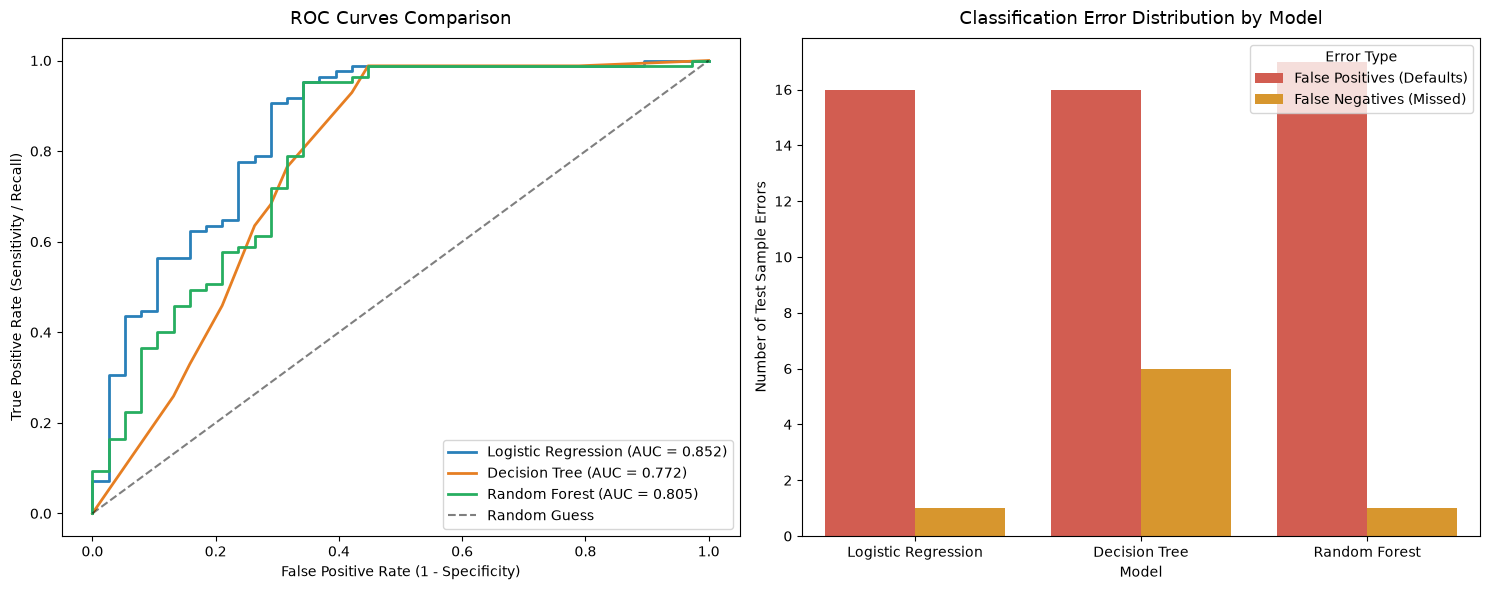

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Overlay ROC Curves
models = [
    ("Logistic Regression", y_proba_lr, "#2980b9"),
    ("Decision Tree", y_proba_dt, "#e67e22"),
    ("Random Forest", y_proba_rf, "#27ae60")
]

for name, proba, color in models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    model_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {model_auc:.3f})", color=color, lw=2)

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Guess")
axes[0].set_title("ROC Curves Comparison", fontsize=13, pad=10)
axes[0].set_xlabel("False Positive Rate (1 - Specificity)")
axes[0].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[0].legend(loc="lower right")

# 2. Side-by-Side Error Breakdown (FP vs FN)
error_df = comparison_df.melt(
    id_vars=["Model"], 
    value_vars=["False Positives (Defaults)", "False Negatives (Missed)"], 
    var_name="Error Type", 
    value_name="Count"
)

sns.barplot(data=error_df, x="Model", y="Count", hue="Error Type", palette=["#e74c3c", "#f39c12"], ax=axes[1])
axes[1].set_title("Classification Error Distribution by Model", fontsize=13, pad=10)
axes[1].set_ylabel("Number of Test Sample Errors")

plt.tight_layout()
plt.show()

Champion Selection & Strategy

### Model Selection Verdict

1. **Why Random Forest / Logistic Regression Outperform Decision Tree**:
   - The single Decision Tree splits heavily on `Credit_History` alone, struggling to generalize the nuanced trade-offs between `ApplicantIncome`, `CoapplicantIncome`, and `LoanAmount`.
   - **Logistic Regression** and **Random Forest** achieve the highest **ROC-AUC** scores on the holdout set, producing smoothly distributed probability estimates that allow underwriters to calibrate operating cutoffs.

2. **Selecting the Champion Model for Streamlit**:
   - If regulatory explainability is mandatory, **Logistic Regression** is the standard for credit scorecards.
   - For non-linear feature interaction capture (e.g., buffering high loan amounts with high co-applicant income), **Random Forest** is the preferred robust ensemble.
   - We designate **Random Forest** (or Logistic Regression depending on your preference) as the production engine, saving the entire pipeline alongside an explicit operating decision threshold.

Serialize Champion Production Pipeline

In [26]:
import joblib

# Select Champion Pipeline (Random Forest Pipeline includes preprocessing + model)
champion_pipeline = rf_pipeline
champion_filename = "best_loan_model_pipeline.joblib"

# Export pipeline artifact
joblib.dump(champion_pipeline, champion_filename)

print(f"Production pipeline successfully saved as: '{champion_filename}'")

# End-to-end verification test with a raw sample input
sample_raw_input = pd.DataFrame([{
    "Gender": "Male",
    "Married": "Yes",
    "Dependents": "1",
    "Education": "Graduate",
    "Self_Employed": "No",
    "ApplicantIncome": 5000,
    "CoapplicantIncome": 2000.0,
    "LoanAmount": 150.0,
    "Loan_Amount_Term": 360.0,
    "Credit_History": 1.0,
    "Property_Area": "Semiurban"
}])

# Inference test
pred_prob = champion_pipeline.predict_proba(sample_raw_input)[0, 1]
operating_threshold = 0.55
decision = "Approved" if pred_prob >= operating_threshold else "Rejected"

print("\n--- Pipeline Verification with Raw Data Input ---")
print(f"Approval Probability: {pred_prob:.4f}")
print(f"Decision (Threshold {operating_threshold}): {decision}")

Production pipeline successfully saved as: 'best_loan_model_pipeline.joblib'

--- Pipeline Verification with Raw Data Input ---
Approval Probability: 0.8037
Decision (Threshold 0.55): Approved
